In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("used_car_price_prediction_1M.csv")
data


,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004995,Nissan,Magnite,2022,12.256422,1773.657889,117.574596,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,1.104233e+06
1004996,Honda,Amaze,2005,NaN,1705.773023,99.643689,CNG,Automatic,First,NaN,Pune,311400,1,1,0,1,4,5,20,7.122346e+05
1004997,Skoda,Octavia,2018,21.665335,1447.159515,NaN,Petrol,NaN,First,Brown,Delhi,42140,0,1,0,1,4,4,7,1.304198e+06
1004998,BMW,X3,2010,17.852635,2179.906631,NaN,Petrol,Manual,First,Brown,Mumbai,211980,0,1,0,1,4,7,15,1.866610e+06


In [3]:
#1.
C1 = np.array(data['Price'])
C1

array([ 353189.6041531 ,  959694.25742199,  292022.92555253, ...,
       1304197.99836824, 1866610.45519211,   50000.        ],
      shape=(1005000,))

In [4]:
#2.
C1.mean()

np.float64(1012896.9603581706)

In [5]:
C1.std()

np.float64(1141644.368391019)

In [6]:
np.median(C1)

np.float64(758908.3198522879)

In [7]:
#3.
C2 = np.array(data[data['Seats']==5])
C2.shape[0]

753629

In [8]:
#4.
C3 = np.array(data[['Engine_CC','Horsepower']])
C3

array([[1396.56037922,           nan],
       [1130.77100465,  137.02171911],
       [1766.46625   ,  142.90296048],
       ...,
       [1447.15951546,           nan],
       [2179.90663067,           nan],
       [ 800.        ,   11.8570822 ]], shape=(1005000, 2))

In [9]:
#5.
C5 = data[data['Engine_CC'] > 2000]
C5[['Brand','Engine_CC']]

,Brand,Engine_CC
10,Mercedes,2128.230552
13,Audi,2365.909008
14,Ford,2049.147919
22,Ford,2023.562538
26,Mahindra,2200.424896
...,...,...
1004974,Toyota,2102.058655
1004976,Skoda,2144.596483
1004981,Ford,2204.412667
1004984,Honda,2015.266064


In [10]:
#6.
C6 = np.array(data['Mileage_kmpl'].fillna(0))
C6.mean()

np.float64(16.556543587572694)

In [11]:
#7.
C7 = np.array(data['Price'])
C7 = np.sort(C7)[::-1]
C7

array([37885997.53319111, 37553759.89470822, 35852892.15006834, ...,
          50000.        ,    50000.        ,    50000.        ],
      shape=(1005000,))

In [12]:
#8.
C8 = data[data['Kms_Driven']>100000].shape[0]
C8

703040

In [13]:
#9.
data[['Horsepower','Price']].corr()

,Horsepower,Price
Horsepower,1.000000,0.044592
Price,0.044592,1.000000


In [14]:
#10.
total = data.shape[0]
req = data[data['Accidents']>=1].shape[0]
(req/total)*100

25.872835820895524

## Pandas

In [15]:
#1,2
data = pd.read_csv("used_car_price_prediction_1M.csv")
data.shape

(1005000, 20)

In [16]:
#3.
data1 = data.groupby('Fuel_Type')
data1.groups.keys()

dict_keys([' Diesel', 'CNG', 'Diesel', 'Electric', 'Hybrid', 'PETROL', 'Petrol', 'diesel ', 'electrik', 'hybridd', 'petrol'])

In [17]:
#4.
data['Transmission'].value_counts()

Transmission
Manual       600630
Automatic    323985
Name: count, dtype: int64

In [18]:
#5.
data2 = data[data['Year']>2018]['Model']
data2

4            Civic
8           Taigun
10         E-Class
12          Seltos
13              Q5
            ...   
1004984      Civic
1004987      Sonet
1004988      Amaze
1004992      Nexon
1004995    Magnite
Name: Model, Length: 241296, dtype: object

In [19]:
#6.
data.sort_values('Price',ascending=False)['Model'].head()


567247        GLA
647346    C-Class
299906        GLA
340898    E-Class
902594    E-Class
Name: Model, dtype: object

In [20]:
#7.
avgM = data.groupby('Fuel_Type')
avgM['Mileage_kmpl'].mean()

Fuel_Type
 Diesel     18.169105
CNG         17.990622
Diesel      17.986752
Electric    17.992420
Hybrid      18.013072
PETROL      17.908679
Petrol      17.996142
diesel      17.960236
electrik    17.945289
hybridd     18.019629
petrol      18.042019
Name: Mileage_kmpl, dtype: float64

In [21]:
#8.
data['City'].value_counts()

City
Delhi        115999
Hyderabad    115854
Mumbai       115777
Pune         115588
Ahmedabad    115480
Bangalore    115471
Kolkata      115405
Chennai      114996
Name: count, dtype: int64

In [22]:
#9.
data3 = data.groupby('Owner_Type')
data3['Price'].mean()

Owner_Type
First      1.013140e+06
Fourth+    1.016552e+06
Second     1.011579e+06
Third      1.012916e+06
Name: Price, dtype: float64

In [23]:
#10
data4 = data.groupby('Brand')
data4['Horsepower'].mean().sort_values(ascending=False).head(1)

Brand
Mahindra     123.414478
Name: Horsepower, dtype: float64

## Matplotlib


Text(0.5, 0, 'Frequency')

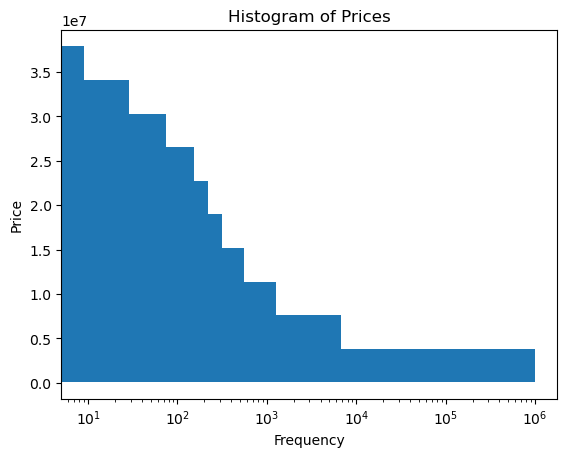

In [24]:
#1.
plt.hist(data['Price'],log=True,orientation = 'horizontal')
plt.title('Histogram of Prices')
plt.ylabel('Price')
plt.xlabel('Frequency')

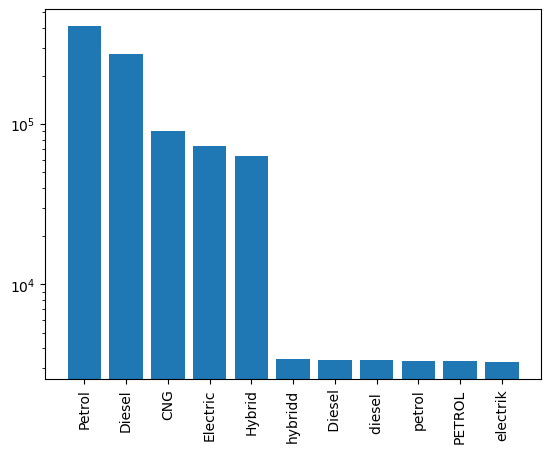

In [25]:
#2.
D1 = data['Fuel_Type'].value_counts()
x=D1.index
y=D1.values
plt.bar(x,y,log=True)
plt.xticks(rotation='vertical')
plt.show()


Text(0, 0.5, 'Average value')

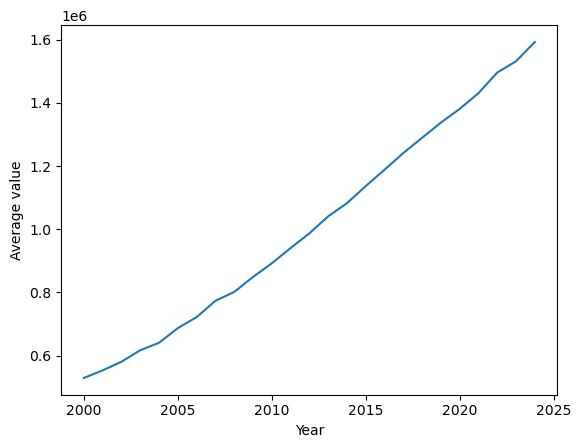

In [26]:
#3.
M2 = data.groupby('Year')['Price'].mean()
x=M2.index
y = M2.values
plt.plot(x,y)
plt.xlabel("Year")
plt.ylabel("Average value")

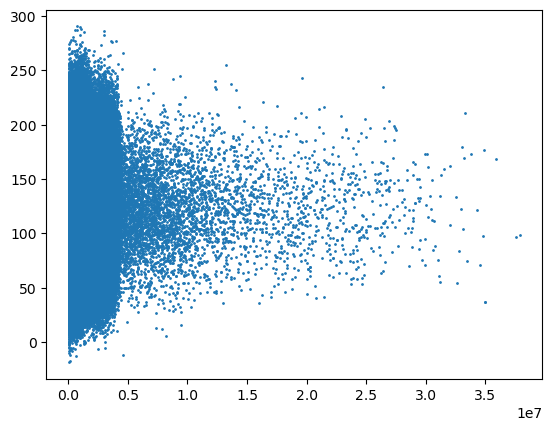

In [27]:
#4.
plt.scatter(data['Price'],data['Horsepower'],s=1)

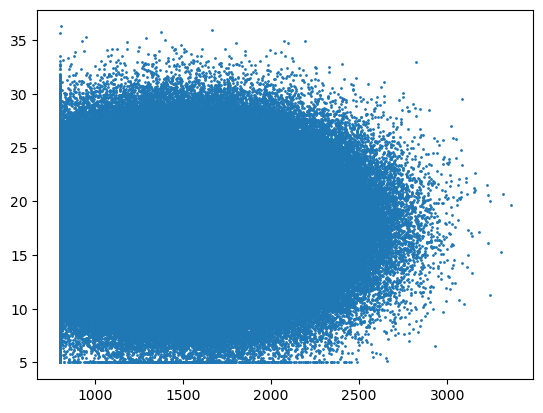

In [28]:
#5.
plt.scatter(data['Engine_CC'],data['Mileage_kmpl'],s=1)


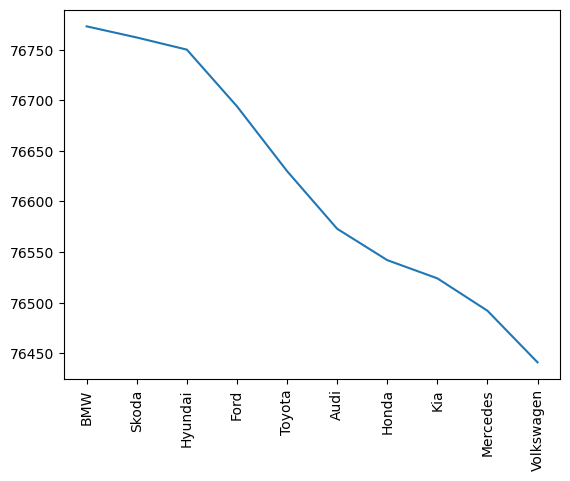

In [29]:
#6.
D3=data['Brand'].value_counts().head(10)
plt.plot(D3.index,D3.values)
plt.xticks(rotation='vertical')
plt.show()

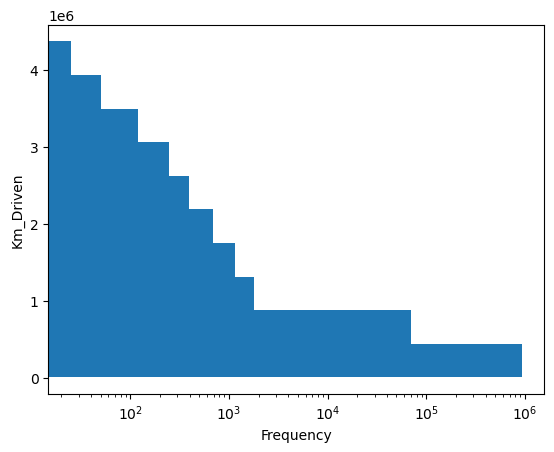

In [30]:
#7.
plt.hist(data['Kms_Driven'],log=True,orientation='horizontal')
plt.xlabel("Frequency")
plt.ylabel("Km_Driven")
plt.show()

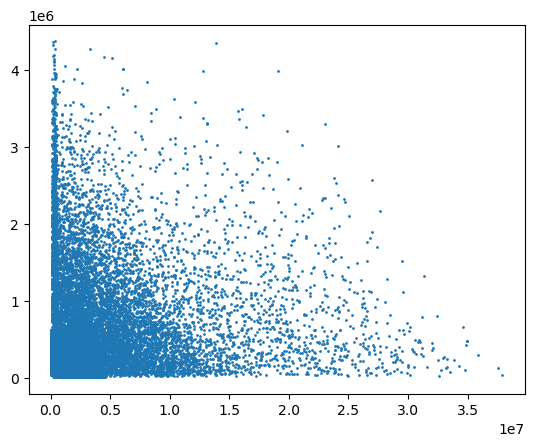

In [31]:
#8.
plt.scatter(data['Price'],data['Kms_Driven'],s=1)

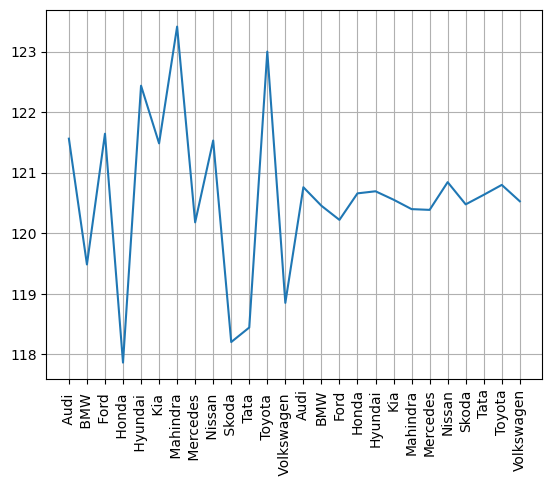

In [32]:
#9.
avgHpower = data.groupby('Brand')['Horsepower'].mean()
plt.plot(avgHpower.index,avgHpower.values)
plt.xticks(rotation='vertical')
plt.grid()
plt.show()


C:\Users\ragha\AppData\Local\Temp\ipykernel_18688\3745296657.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([m,a],labels=['Manual','Automatic'])


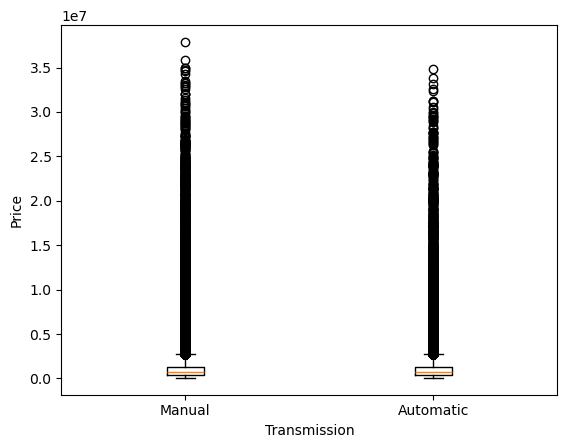

In [37]:
#10
m = data[data['Transmission']== 'Manual']['Price']
a = data[data['Transmission']== 'Automatic']['Price']
plt.boxplot([m,a],labels=['Manual','Automatic'])
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.show()